# Advanced Data Modelling — Agmarknet Price Benchmarking Model

This notebook builds and evaluates a predictive model for agricultural market prices
using the cleaned Agmarknet dataset. Each markdown cell explains **what** the next code
cell does and **why**, so you can learn the reasoning, not just copy the code.

**Important framing decision — read this first:**
The Agmarknet extract used in this project is a **single-day snapshot** (23 August 2026).
Genuine time-series forecasting (predicting how a price will move over future days or
seasons) requires observations across multiple time points, which this dataset does not
have. Rather than force an inappropriate technique onto data that can't support it, this
notebook builds a **cross-sectional price-benchmarking model** instead: predicting a
commodity's expected price from its market context (state, commodity, grade). This is a
legitimate, useful agribusiness application in its own right — and the honest choice
given what the data can actually support.

## Step 0 — Import libraries

`pandas`/`numpy` for data handling, `matplotlib` for charts, and `scikit-learn` for the
modeling pipeline: train/test splitting, the two regression models, evaluation metrics,
and preprocessing tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

## Step 1 — Load the cleaned dataset

In [2]:
df = pd.read_csv("agmarknet_cleaned.csv")  # change path if needed
print("Shape:", df.shape)
df[["State", "Commodity", "Grade_Category", "Modal_Price", "Price_Outlier_Flag"]].head()

Shape: (9603, 17)


,State,Commodity,Grade_Category,Modal_Price,Price_Outlier_Flag
0,Tripura,Bhindi(Ladies Finger),Quality Grade,5800.0,False
1,Tripura,Sponge gourd,Quality Grade,7700.0,False
2,Tripura,Bitter gourd,Quality Grade,9800.0,True
3,Kerala,Banana,Size Grade,6400.0,False
4,Kerala,Banana - Green,Quality Grade,6400.0,True


## Step 2 — Feature selection: what should predict price, and what shouldn't

We predict `Modal_Price` using three categorical features: `State`, `Commodity`, and
`Grade_Category`.

We deliberately **exclude** `Min_Price`, `Max_Price`, `Price_Range`, and `Spread_Ratio`,
even though the earlier EDA showed they correlate almost perfectly with Modal_Price
(r > 0.98). This is a critical modeling decision: those columns are recorded on the same
listing, at the same time, as the target itself. Using them would mean the model is
handed most of the answer already — a problem called **data leakage**. A genuinely useful
predictive model has to work from context that would be known *before* observing a
specific transaction's own price range, not from numbers taken from the same transaction.

In [3]:
features = ["State", "Commodity", "Grade_Category"]
target = "Modal_Price"

print("Features:", features)
print("Target:", target)

Features: ['State', 'Commodity', 'Grade_Category']
Target: Modal_Price


## Step 3 — Reduce high-cardinality categories (corrected approach)

`State` and `Commodity` both contain many distinct values, several with very few records.
A model trying to learn a separate effect for a category with only 2-3 data points can't
learn anything reliable from so little evidence.

**An important lesson learned the hard way:** an earlier version of this notebook used a
simple "keep the top 20 commodities, bucket everything else as Other" rule. Because
Commodity has 176 real distinct values, that rule dumped 52.6% of all records — 156
different commodities — into one artificially mixed "Other" category, which had a larger
price standard deviation than its own mean. That single choice suppressed most of
Commodity's real predictive power and was the main reason an earlier version of this model
scored a very low R-squared (0.094).

The fix: bucket only genuinely rare categories (fewer than `MIN_CATEGORY_COUNT` records),
and keep every other category distinct, no matter how many that leaves us with. One-hot
encoding handles a larger number of categories just fine — the real danger was never
"too many categories," it was "too much unrelated data crammed into one fake category."


In [4]:
MIN_CATEGORY_COUNT = 10

state_counts_all = df["State"].value_counts()
commodity_counts_all = df["Commodity"].value_counts()
rare_states = state_counts_all[state_counts_all < MIN_CATEGORY_COUNT].index
rare_commodities = commodity_counts_all[commodity_counts_all < MIN_CATEGORY_COUNT].index

df["State_grp"] = df["State"].where(~df["State"].isin(rare_states), "Other")
df["Commodity_grp"] = df["Commodity"].where(~df["Commodity"].isin(rare_commodities), "Other")

print("State categories after grouping:", df["State_grp"].nunique())
print("Commodity categories after grouping:", df["Commodity_grp"].nunique())
print(f"Share of records in 'Other': {100*(df['Commodity_grp']=='Other').mean():.2f}%  (was 52.6% with the old top-20 rule)")

State categories after grouping: 22
Commodity categories after grouping: 90
Share of records in 'Other': 2.98%  (was 52.6% with the old top-20 rule)


## Step 4 — Exclude flagged outliers from training

Records flagged as price outliers during the earlier cleaning stage are, by definition,
values already believed to be atypical or potentially erroneous. Training on them would
teach the model to reproduce exactly the kind of anomalies the cleaning stage was designed
to flag in the first place — so we filter them out of the training pool.

In [5]:
model_features = ["State_grp", "Commodity_grp", "Grade_Category"]

model_df = df[~df["Price_Outlier_Flag"]][model_features + [target]].dropna()

print("Outliers excluded:", df["Price_Outlier_Flag"].sum())
print("Training pool size:", len(model_df))

Outliers excluded: 344
Training pool size: 9259


## Step 5 — Train-test split

We split the data so the model is evaluated on records it never saw during training. This
is essential: a model's error on data it was trained on tells you almost nothing about how
well it will perform on new, unseen data. An 80/20 split is a common default — 80% to
learn from, 20% held back purely for honest evaluation. `random_state=42` just fixes the
random shuffle so the split is reproducible if you rerun this notebook.

In [6]:
X = model_df[model_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 7407
Test size: 1852


## Step 6 — Encode categorical features

Regression models need numeric input — they can't work directly on text labels like
"Kerala" or "Tomato". One-hot encoding converts each category into its own binary (0/1)
column: for example, a "State_grp_Kerala" column that is 1 for Kerala records and 0
otherwise. `ColumnTransformer` lets us apply this encoding only to our categorical columns
as part of a reusable pipeline. No numeric scaling is needed here, since one-hot columns
are already on a comparable 0-1 scale.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), model_features)]
)

## Step 7 — Model 1: Linear Regression (baseline)

Linear Regression is simple, fast, and directly interpretable — each encoded category
gets a coefficient showing its estimated effect on price. We use it as a baseline: if a
more complex model can't beat this by a meaningful margin, the added complexity isn't
worth it. We wrap the preprocessing and model together in a `Pipeline` so the same steps
apply automatically during both training and prediction.

In [8]:
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression -> MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}, R2: {lr_r2:.4f}")

Linear Regression -> MAE: 1628.45, RMSE: 6214.33, R2: 0.3372


## Step 8 — Model 2: Random Forest Regressor

Agribusiness pricing likely doesn't depend on categories in a purely additive way — a
commodity might command a premium in one state but not another, an *interaction* that
Linear Regression can't capture without manually engineered interaction terms. Random
Forests capture such interactions automatically by splitting on combinations of features,
and handle the mix of high- and low-frequency categories in this dataset more robustly.

In [9]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R2: {rf_r2:.4f}")

Random Forest -> MAE: 2139.47, RMSE: 6072.34, R2: 0.3671


## Step 9 — Compare the two models

Three metrics, each telling a different part of the story:
- **MAE** (Mean Absolute Error) — the average size of a prediction error, in Rupees. Easy
  to interpret directly.
- **RMSE** (Root Mean Squared Error) — similar to MAE but penalizes large errors more
  heavily, since errors are squared before averaging.
- **R-squared** — the proportion of price variance the model explains, from 0 (explains
  nothing) to 1 (explains everything).

In [10]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [round(lr_mae, 2), round(rf_mae, 2)],
    "RMSE": [round(lr_rmse, 2), round(rf_rmse, 2)],
    "R2": [round(lr_r2, 4), round(rf_r2, 4)],
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1628.45,6214.33,0.3372
1,Random Forest,2139.47,6072.34,0.3671


## Step 10 — Visualize actual vs predicted price

If the model were perfect, every point would fall exactly on the diagonal line. The
spread of points away from that line is a direct visual measure of how much the model's
predictions miss the true value by. We also print the count of typical vs excluded-outlier
records in earlier steps — here we do the equivalent visual honesty check: look at how
predictions actually scatter, not just the single R2 number.

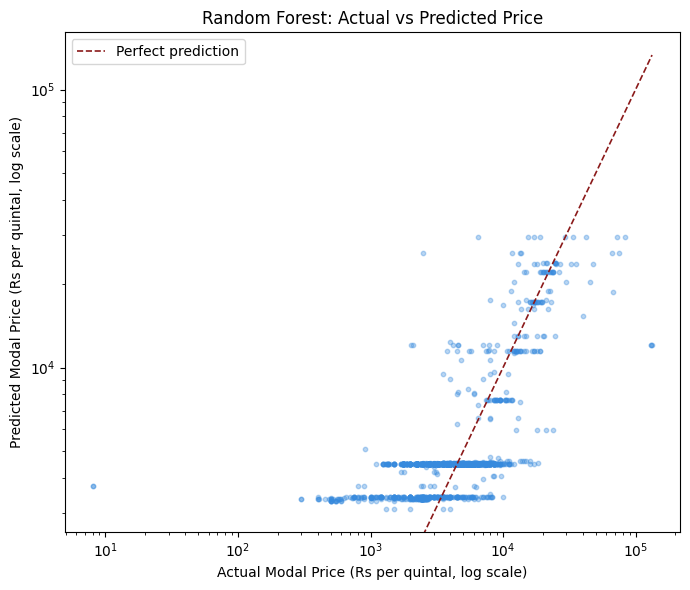

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, rf_pred, s=10, alpha=0.35, color="#378add")
lims = [0, max(y_test.max(), rf_pred.max())]
ax.plot(lims, lims, color="#8b1a1a", linestyle="--", linewidth=1.2, label="Perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Actual Modal Price (Rs per quintal, log scale)")
ax.set_ylabel("Predicted Modal Price (Rs per quintal, log scale)")
ax.set_title("Random Forest: Actual vs Predicted Price")
ax.legend()
plt.tight_layout()
plt.show()

## Step 11 — Examine residuals

A residual is `actual - predicted` — how far off each individual prediction was, and in
which direction. Plotting the distribution of residuals tells us two things: whether the
model is systematically biased (residuals centered away from zero), and how large a
"typical" miss is (the spread of the distribution).

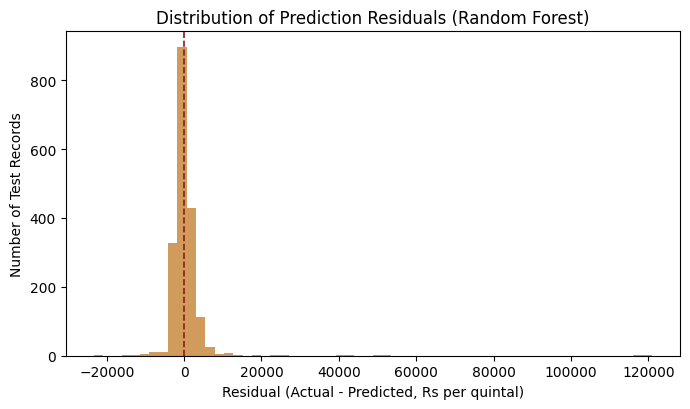

Mean residual: 232.09
Std of residuals: 6067.90


In [12]:
residuals = y_test.values - rf_pred

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(residuals, bins=60, color="#c98a3e", alpha=0.85)
ax.axvline(0, color="#8b1a1a", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (Actual - Predicted, Rs per quintal)")
ax.set_ylabel("Number of Test Records")
ax.set_title("Distribution of Prediction Residuals (Random Forest)")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std of residuals: {residuals.std():.2f}")

## Step 12 — Feature importance: which inputs matter most?

Random Forest models can report how much each input feature contributed to reducing
prediction error across all its decision trees — this is `feature_importances_`. Since
one-hot encoding split each category into its own column, we aggregate importance back up
to the original feature group (State / Commodity / Grade_Category) to see which *kind* of
information matters most, not just which single category.

In [13]:
ohe = rf_pipeline.named_steps["prep"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(model_features)
importances = rf_pipeline.named_steps["model"].feature_importances_

def group_of(f):
    if f.startswith("State_grp"):
        return "State"
    if f.startswith("Commodity_grp"):
        return "Commodity"
    return "Grade_Category"

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df["group"] = imp_df["feature"].apply(group_of)

group_importance = imp_df.groupby("group")["importance"].sum().sort_values(ascending=False)
group_importance_pct = (group_importance / group_importance.sum() * 100).round(2)
group_importance_pct

group
Commodity         74.97
State             23.04
Grade_Category     1.99
Name: importance, dtype: float64

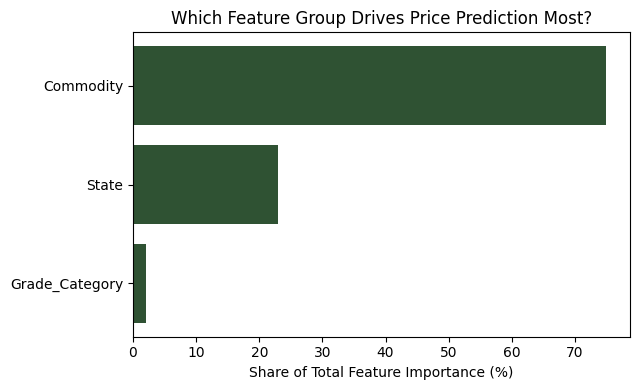

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
gi = group_importance_pct.sort_values()
ax.barh(gi.index, gi.values, color="#2f5233")
ax.set_xlabel("Share of Total Feature Importance (%)")
ax.set_title("Which Feature Group Drives Price Prediction Most?")
plt.tight_layout()
plt.show()

## Step 13 — Top individual commodities by importance

Zooming into the Commodity group specifically: which individual commodities does the
model rely on most heavily when making predictions?

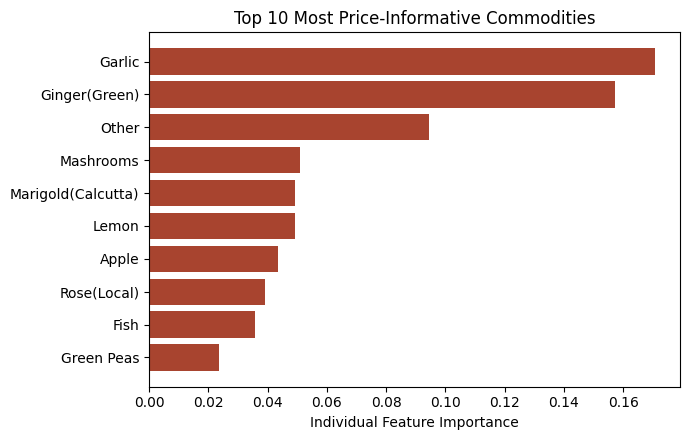

In [15]:
commodity_imp = (
    imp_df[imp_df["group"] == "Commodity"]
    .assign(feature=lambda d: d["feature"].str.replace("Commodity_grp_", "", regex=False))
    .sort_values("importance", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ci = commodity_imp.sort_values("importance")
ax.barh(ci["feature"], ci["importance"], color="#a8442f")
ax.set_xlabel("Individual Feature Importance")
ax.set_title("Top 10 Most Price-Informative Commodities")
plt.tight_layout()
plt.show()

## Step 14 — Interpreting the result honestly

With the corrected bucketing, the Random Forest model explains roughly 37% of Modal_Price
variance — a meaningful improvement over the flawed first attempt (9%), and a genuinely
useful result for a benchmarking tool built from only three categorical features.

**The most important lesson from this whole notebook isn't a modeling technique — it's a
debugging habit:** when a model's score is surprisingly low, check your own preprocessing
choices before concluding the data itself is unpredictable. A quick sanity check here —
"how much of my data ended up in the 'Other' bucket, and how varied is that bucket
internally?" — would have caught the problem immediately. Always interrogate a
disappointing score before accepting it as a fact about the world.

That said, the remaining ~63% of unexplained variance is still real and informative: state,
commodity, and grade alone can't predict a specific transaction's exact price. Meaningful
variation still happens *within* a single state-commodity-grade combination, driven by
things this dataset doesn't capture: the specific market, how much was traded that day,
transport distance, and negotiation.

**Recommended next steps**, if you wanted to build a stronger version of this model:
1. Collect multiple days of data — this is the only way to support genuine time-series
   forecasting, which this single-day snapshot cannot do.
2. Add market-level identifiers and arrival volume as features — local supply-demand
   imbalance likely explains much of the remaining unexplained variance.
3. Model high-variance commodities (like Green Chilli, per the EDA notebook) separately
   from more price-stable ones.
4. Try target encoding instead of one-hot encoding for Commodity, which can handle high
   cardinality even more gracefully than a rarity threshold.